# PDEBench-Lang: Cross-Dialect Comparison
Trains one T5-small model per dialect (natural, latex, prefix, postfix) on the **same** dataset split.  
Compares family accuracy, operator F1, reasoning ROUGE-L, and Trash Score across dialects.

**Experimental control:** only the input dialect changes — architecture, hyperparameters, and data split are identical across all four runs.

## 1. Setup

In [53]:
!pip install -q transformers datasets evaluate rouge_score scikit-learn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [54]:
import json
import random
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split
from transformers import (
    T5Tokenizer, T5ForConditionalGeneration,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset
import evaluate

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'MPS available   : {torch.backends.mps.is_available()}')

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Device          : {device}')

PyTorch version : 2.11.0
CUDA available  : False
MPS available   : True
Device          : mps


In [55]:
CONFIG = {
    'model_name'       : 't5-small',
    'dataset_path'     : 'varied_data_generation/dataset.jsonl',
    'dialects'         : ['natural', 'latex', 'prefix', 'postfix'],
    'max_input_length' : 256,   # latex strings are long
    'max_output_length': 256,
    'learning_rate'    : 3e-4,
    'batch_size'       : 16,
    'num_epochs'       : 3,
    'train_split'      : 0.8,
    'val_split'        : 0.1,
    'test_split'       : 0.1,
    'seed'             : 42,
}

random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
print('Config loaded.')

Config loaded.


## 2. Load & Split Data (done ONCE — shared across all models)

In [56]:
def load_dataset(path):
    data = []
    with open(path) as f:
        for line in f:
            data.append(json.loads(line.strip()))
    return data

all_data = load_dataset(CONFIG['dataset_path'])
print(f'Total instances: {len(all_data)}')
print('Family distribution:', dict(Counter(d['family'] for d in all_data)))

Total instances: 10000
Family distribution: {'Advection': 2000, 'Burgers': 2000, 'Heat': 2000, 'Wave': 2000, 'Laplace': 2000}


In [57]:
# Stratified split by family — done once, reused for all 4 dialect models
train_val, test_data = train_test_split(
    all_data,
    test_size=CONFIG['test_split'],
    stratify=[d['family'] for d in all_data],
    random_state=CONFIG['seed']
)
train_data, val_data = train_test_split(
    train_val,
    test_size=CONFIG['val_split'] / (CONFIG['train_split'] + CONFIG['val_split']),
    stratify=[d['family'] for d in train_val],
    random_state=CONFIG['seed']
)

print(f'Train : {len(train_data)}')
print(f'Val   : {len(val_data)}')
print(f'Test  : {len(test_data)}')
print('\nTest family distribution:', dict(Counter(d['family'] for d in test_data)))

Train : 7999
Val   : 1001
Test  : 1000

Test family distribution: {'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Advection': 200, 'Wave': 200}


## 3. Output Format & Helpers

In [58]:
# --------------------------------------------------------------------------
# Output format fed to T5 during training:
#   family: Heat | operators: exp, polynomial | reasoning: <text>
# --------------------------------------------------------------------------

def build_target(instance):
    ops = ', '.join(instance['labels']['operators'])
    reasoning = instance['labels']['reasoning']
    family = instance['labels']['behavioral']
    return f"family: {family} | operators: {ops} | reasoning: {reasoning}"


def parse_prediction(pred):
    """Extract family, operators, and reasoning from model output string."""
    result = {'family': None, 'operators': [], 'reasoning': ''}
    try:
        parts = pred.split(' | ')
        for part in parts:
            part = part.strip()
            if part.startswith('family:'):
                result['family'] = part.replace('family:', '').strip()
            elif part.startswith('operators:'):
                ops_str = part.replace('operators:', '').strip()
                result['operators'] = [o.strip() for o in ops_str.split(',') if o.strip()]
            elif part.startswith('reasoning:'):
                result['reasoning'] = part.replace('reasoning:', '').strip()
    except Exception:
        pass
    return result


# Structural keywords that MUST appear in reasoning for it to be considered correct.
# A prediction with the right family but none of these keywords = Trash.
REASONING_KEYWORDS = {
    'Heat'     : ['first-order time', 'second-order spatial', 'diffus'],
    'Wave'     : ['second-order time', 'wave', 'speed'],
    'Burgers'  : ['nonlinear', 'convect', 'viscosit', 'u*u_x'],
    'Laplace'  : ['steady', 'no time', 'equilibrium', 'u_xx'],
    'Advection': ['transport', 'advect', 'first-order'],
}


def is_reasoning_correct(family, reasoning_text):
    """Returns True if reasoning contains at least one structural keyword for the family."""
    keywords = REASONING_KEYWORDS.get(family, [])
    reasoning_lower = reasoning_text.lower()
    return any(kw.lower() in reasoning_lower for kw in keywords)


print('Helpers defined.')
# Quick sanity check
sample = all_data[0]
print('Sample target:', build_target(sample))

Helpers defined.
Sample target: family: Advection | operators: exp, polynomial | reasoning: No second-order spatial derivative; only u_t and 1.23*u_x appear — this is advection, not diffusion, at speed 1.23.


## 4. Tokenisation

In [59]:
tokenizer = T5Tokenizer.from_pretrained(CONFIG['model_name'])

def prepare_hf_dataset(data, dialect):
    """Build a HuggingFace Dataset for one dialect."""
    inputs  = [d['dialects'][dialect] for d in data]
    targets = [build_target(d) for d in data]

    def tokenize(batch):
        model_inputs = tokenizer(
            batch['input'],
            max_length=CONFIG['max_input_length'],
            truncation=True,
            padding='max_length',
        )
        labels = tokenizer(
            text_target=batch['target'],
            max_length=CONFIG['max_output_length'],
            truncation=True,
            padding='max_length',
        )
        model_inputs['labels'] = labels['input_ids']
        return model_inputs

    hf = Dataset.from_dict({'input': inputs, 'target': targets})
    return hf.map(tokenize, batched=True, remove_columns=['input', 'target'])

print('Tokeniser ready.')

Tokeniser ready.


## 5. Train & Evaluate — One Function per Dialect

In [60]:
rouge = evaluate.load('rouge')


def compute_metrics(test_data, predictions_raw):
    parsed = [parse_prediction(p) for p in predictions_raw]

    # 1. Family accuracy
    correct_family = sum(
        1 for d, p in zip(test_data, parsed)
        if p['family'] and p['family'].lower() == d['family'].lower()
    )
    family_acc = correct_family / len(test_data)

    # 2. Operator precision / recall / F1
    total_precision, total_recall, n = 0.0, 0.0, 0
    for d, p in zip(test_data, parsed):
        true_ops = set(d['labels']['operators'])
        pred_ops = set(o.lower() for o in p['operators'])
        if not pred_ops and not true_ops:
            total_precision += 1.0
            total_recall    += 1.0
        elif pred_ops:
            tp = len(true_ops & pred_ops)
            total_precision += tp / len(pred_ops)
            total_recall    += tp / len(true_ops) if true_ops else 0.0
        n += 1
    prec  = total_precision / n
    rec   = total_recall    / n
    op_f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    # 3. Reasoning ROUGE-L
    true_reasoning = [d['labels']['reasoning'] for d in test_data]
    pred_reasoning = [p['reasoning'] for p in parsed]
    rouge_scores = rouge.compute(
        predictions=pred_reasoning,
        references=true_reasoning,
        rouge_types=['rougeL']
    )
    rouge_l = rouge_scores['rougeL']

    # 4. Trash Score
    trash_count = 0
    for d, p in zip(test_data, parsed):
        label_correct = p['family'] and p['family'].lower() == d['family'].lower()
        reasoning_ok  = is_reasoning_correct(d['family'], p['reasoning'])
        if label_correct and not reasoning_ok:
            trash_count += 1
    trash_score = trash_count / len(test_data)

    return {
        'family_accuracy'   : family_acc,
        'operator_precision': prec,
        'operator_recall'   : rec,
        'operator_f1'       : op_f1,
        'reasoning_rouge_l' : rouge_l,
        'trash_score'       : trash_score,
        'trash_count'       : trash_count,
        'n'                 : len(test_data),
    }


def get_best_checkpoint(output_dir):
    if not os.path.isdir(output_dir):
        return None
    checkpoints = [
        os.path.join(output_dir, d) for d in os.listdir(output_dir)
        if d.startswith('checkpoint-')
    ]
    if not checkpoints:
        return None
    return sorted(checkpoints, key=lambda x: int(x.split('-')[-1]))[-1]


def run_dialect(dialect):
    print(f'\n{"="*60}')
    print(f'  DIALECT: {dialect.upper()}')
    print(f'{"="*60}')

    output_dir = f'./models/{dialect}'
    existing_checkpoint = get_best_checkpoint(output_dir)

    if existing_checkpoint:
        print(f'Found existing checkpoint: {existing_checkpoint}')
        print('Skipping training, loading saved model...')
        model = T5ForConditionalGeneration.from_pretrained(existing_checkpoint)
    else:
        train_tok = prepare_hf_dataset(train_data, dialect)
        val_tok   = prepare_hf_dataset(val_data,   dialect)
        print(f'Train: {len(train_tok)} | Val: {len(val_tok)}')

        model = T5ForConditionalGeneration.from_pretrained(CONFIG['model_name'])
        model.to(device)

        training_args = Seq2SeqTrainingArguments(
            output_dir=output_dir,
            num_train_epochs=CONFIG['num_epochs'],
            per_device_train_batch_size=CONFIG['batch_size'],
            per_device_eval_batch_size=CONFIG['batch_size'],
            learning_rate=CONFIG['learning_rate'],
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='eval_loss',
            predict_with_generate=True,
            generation_max_length=CONFIG['max_output_length'],
            fp16=False,
            seed=CONFIG['seed'],
            logging_steps=50,
            report_to='none',
        )

        data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

        trainer = Seq2SeqTrainer(
            model=model,
            args=training_args,
            train_dataset=train_tok,
            eval_dataset=val_tok,
            processing_class=tokenizer,
            data_collator=data_collator,
        )

        trainer.train()
        print(f'Training done for {dialect}.')

    # Inference always on CPU — avoids MPS beam search bug
    print('Generating predictions on test set...')
    model.eval()
    model.to('cpu')
    predictions_raw = []

    for i in range(0, len(test_data), 16):
        batch = test_data[i:i+16]
        inputs_text = [d['dialects'][dialect] for d in batch]
        enc = tokenizer(
            inputs_text,
            return_tensors='pt',
            max_length=CONFIG['max_input_length'],
            truncation=True,
            padding=True,
        )
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=CONFIG['max_output_length'])
        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        predictions_raw.extend(decoded)

    metrics = compute_metrics(test_data, predictions_raw)
    metrics['dialect'] = dialect

    print(f"  Family Accuracy  : {metrics['family_accuracy']:.2%}")
    print(f"  Operator F1      : {metrics['operator_f1']:.2%}")
    print(f"  Reasoning ROUGE-L: {metrics['reasoning_rouge_l']:.2%}")
    print(f"  Trash Score      : {metrics['trash_score']:.2%}  ({metrics['trash_count']}/{metrics['n']} instances)")

    del model
    return metrics


print('Functions defined.')

Functions defined.


## 6. Run All Four Dialects

In [61]:
all_results = []

for dialect in CONFIG['dialects']:
    metrics = run_dialect(dialect)
    all_results.append(metrics)

print('\nAll dialects complete.')


  DIALECT: NATURAL
Found existing checkpoint: ./models/natural/checkpoint-1500
Skipping training, loading saved model...


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 3834.45it/s]

Generating predictions on test set...


  Family Accuracy  : 100.00%
  Operator F1      : 100.00%
  Reasoning ROUGE-L: 44.49%
  Trash Score      : 0.00%  (0/1000 instances)

  DIALECT: LATEX
Found existing checkpoint: ./models/latex/checkpoint-1500
Skipping training, loading saved model...


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 19381.09it/s]

...

Generating predictions on test set...


  Family Accuracy  : 100.00%
  Operator F1      : 100.00%
  Reasoning ROUGE-L: 44.92%
  Trash Score      : 0.00%  (0/1000 instances)

  DIALECT: POSTFIX
Found existing checkpoint: ./models/postfix/checkpoint-1500
Skipping training, loading saved model...


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 4820.79it/s]

Generating predictions on test set...


  Family Accuracy  : 100.00%
  Operator F1      : 100.00%
  Reasoning ROUGE-L: 45.37%
  Trash Score      : 0.00%  (0/1000 instances)

All dialects complete.


## 7. Comparison Table

In [62]:
rows = []
for m in all_results:
    rows.append({
        'Dialect'         : m['dialect'].capitalize(),
        'Family Acc'      : f"{m['family_accuracy']:.2%}",
        'Op Precision'    : f"{m['operator_precision']:.2%}",
        'Op Recall'       : f"{m['operator_recall']:.2%}",
        'Op F1'           : f"{m['operator_f1']:.2%}",
        'ROUGE-L'         : f"{m['reasoning_rouge_l']:.2%}",
        'Trash Score'     : f"{m['trash_score']:.2%}",
    })

df = pd.DataFrame(rows).set_index('Dialect')
print('\n=== CROSS-DIALECT RESULTS (T5-small) ===')
display(df)


=== CROSS-DIALECT RESULTS (T5-small) ===


,Family Acc,Op Precision,Op Recall,Op F1,ROUGE-L,Trash Score
Dialect,,,,,,
Natural,100.00%,100.00%,100.00%,100.00%,44.49%,0.00%
Latex,100.00%,100.00%,100.00%,100.00%,45.66%,0.00%
Prefix,100.00%,100.00%,100.00%,100.00%,44.92%,0.00%
Postfix,100.00%,100.00%,100.00%,100.00%,45.37%,0.00%


In [63]:
# Save raw results for later analysis
with open('dialect_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('Results saved to dialect_results.json')

Results saved to dialect_results.json


## 8. Trash Score Deep Dive

In [64]:
# Re-run inference on the best and worst dialect to show trash examples
# (Run this cell after the main loop completes)

sorted_results = sorted(all_results, key=lambda x: x['trash_score'])
best_dialect  = sorted_results[0]['dialect']
worst_dialect = sorted_results[-1]['dialect']

print(f'Best  Trash Score: {best_dialect}  ({sorted_results[0]["trash_score"]:.2%})')
print(f'Worst Trash Score: {worst_dialect} ({sorted_results[-1]["trash_score"]:.2%})')

print(f'\nThe hypothesis (LaTeX < Postfix trash score) is: ', end='')
latex_trash   = next(m['trash_score'] for m in all_results if m['dialect'] == 'latex')
postfix_trash = next(m['trash_score'] for m in all_results if m['dialect'] == 'postfix')
if latex_trash < postfix_trash:
    print(f'SUPPORTED  (latex={latex_trash:.2%} < postfix={postfix_trash:.2%})')
else:
    print(f'NOT SUPPORTED (latex={latex_trash:.2%} >= postfix={postfix_trash:.2%})')

Best  Trash Score: natural  (0.00%)
Worst Trash Score: postfix (0.00%)

The hypothesis (LaTeX < Postfix trash score) is: NOT SUPPORTED (latex=0.00% >= postfix=0.00%)


## 9. Visualisation

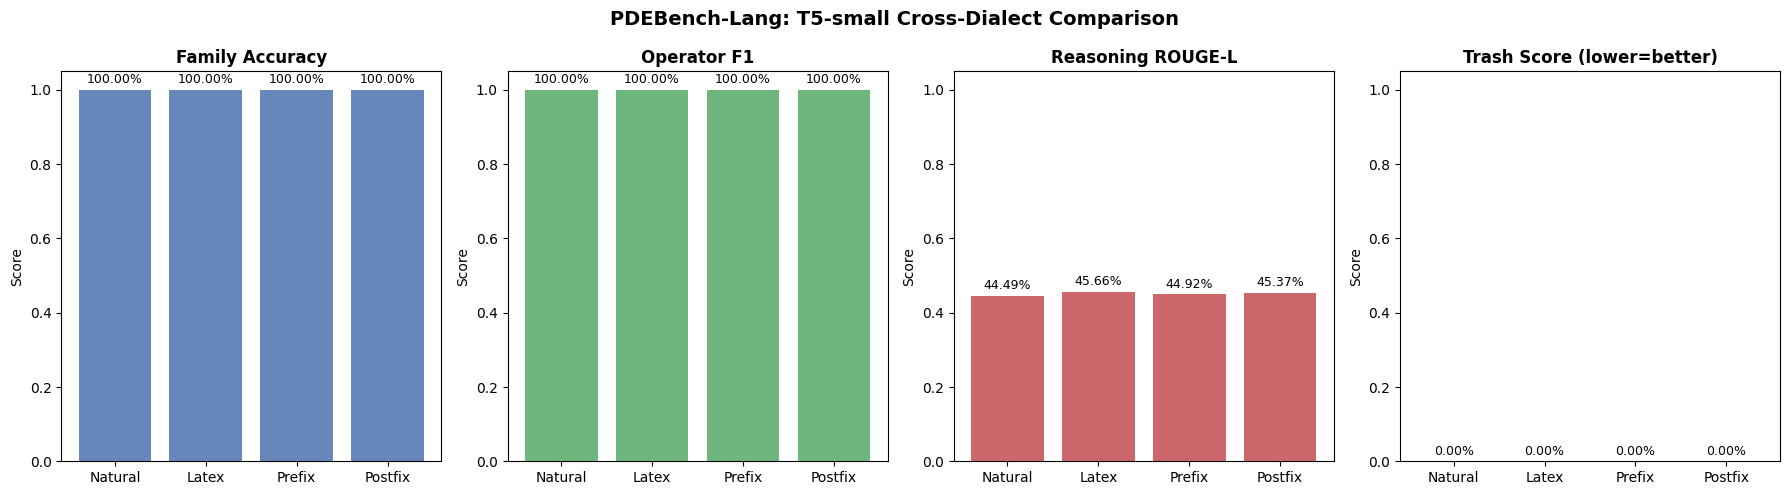

Plot saved to dialect_comparison.png


In [65]:
import matplotlib.pyplot as plt

dialects = [m['dialect'].capitalize() for m in all_results]
metrics_to_plot = {
    'Family Accuracy'    : [m['family_accuracy']    for m in all_results],
    'Operator F1'        : [m['operator_f1']        for m in all_results],
    'Reasoning ROUGE-L'  : [m['reasoning_rouge_l']  for m in all_results],
    'Trash Score (lower=better)': [m['trash_score'] for m in all_results],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, (title, values), color in zip(axes, metrics_to_plot.items(), colors):
    bars = ax.bar(dialects, values, color=color, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2%}', ha='center', va='bottom', fontsize=9)

plt.suptitle('PDEBench-Lang: T5-small Cross-Dialect Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dialect_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to dialect_comparison.png')